In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the cleaned dataset
df = pd.read_csv('data/cleaned_model_data.csv')
leaky_cols = [
    'market_value_in_eur_y', 
    'highest_market_value_in_eur', 
    'current_club_id_x', # IDs don't carry mathematical weight
    'current_club_id_y'
]
df = df.drop(columns=[col for col in leaky_cols if col in df.columns])
# ==========================================
# FEATURE ENGINEERING: DATES TO NUMBERS
# ==========================================
date_cols = ['date', 'date_of_birth', 'contract_expiration_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Calculate exact age at the time of valuation
if 'date_of_birth' in df.columns and 'date' in df.columns:
    df['age_at_val'] = (df['date'] - df['date_of_birth']).dt.days / 365.25

# Calculate days left on contract at the time of valuation
if 'contract_expiration_date' in df.columns and 'date' in df.columns:
    df['contract_days_left'] = (df['contract_expiration_date'] - df['date']).dt.days
    # If contract info is missing, assume 0 days (or you can use median)
    df['contract_days_left'] = df['contract_days_left'].fillna(0)

# Drop the raw date formats now that we have the math
df = df.drop(columns=[c for c in date_cols if c in df.columns])

# ==========================================
# CATEGORICAL ENGINEERING: STRINGS TO COLUMNS
# ==========================================
# Keep the most important unique text features
cat_cols = ['position', 'foot', 'team', 'league', 'nation', 'agent_name']
cat_cols = [c for c in cat_cols if c in df.columns]

# Drop redundant text features to prevent memory overload (OOM crash)
redundant_cols = [
    'current_club_name_x', 'current_club_name_y', 'squad', 'comp', 
    'current_club_domestic_competition_id', 'player_club_domestic_competition_id',
    'country_of_citizenship', 'country_of_birth', 'city_of_birth'
]
df = df.drop(columns=[c for c in redundant_cols if c in df.columns])

# Fill missing text with "Unknown" so the encoder doesn't crash
df[cat_cols] = df[cat_cols].fillna('Unknown')

# ==========================================
# PIPELINE AND TRAINING
# ==========================================
y = np.log1p(df['market_value_in_eur_x'])
X = df.drop(columns=['market_value_in_eur_x'])

# Ensure X only contains our specified categoricals and remaining numeric columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X = X[cat_cols + num_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use handle_unknown='ignore' so rare agents/nations in the test set don't break the model
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

print("Encoding features... (this might take a few seconds due to the high number of agents/teams)")
X_train_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out()
)
X_test_encoded = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out()
)

print(f"Features expanded to {X_train_encoded.shape[1]} columns!")

# Fit the baseline Random Forest
rf_baseline = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf_baseline.fit(X_train_encoded, y_train)

# Evaluate
y_pred = rf_baseline.predict(X_test_encoded)
r2 = r2_score(y_test, y_pred)
rmse_euros = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))

print(f"Baseline R²: {r2:.4f}")
print(f"Baseline RMSE: €{rmse_euros:,.2f}")

Encoding features... (this might take a few seconds due to the high number of agents/teams)
Features expanded to 164 columns!
Baseline R²: 0.6727
Baseline RMSE: €14,466,594.91


Starting Hyperparameter Tuning... (This may take a few minutes)
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.5s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.6s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.6s
[CV] END max_depth=25, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.6s
[CV] END max_depth=25, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.5s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=15, max_fea

/tmp/ipykernel_45648/2276772083.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, ax=axes[2], palette='viridis')


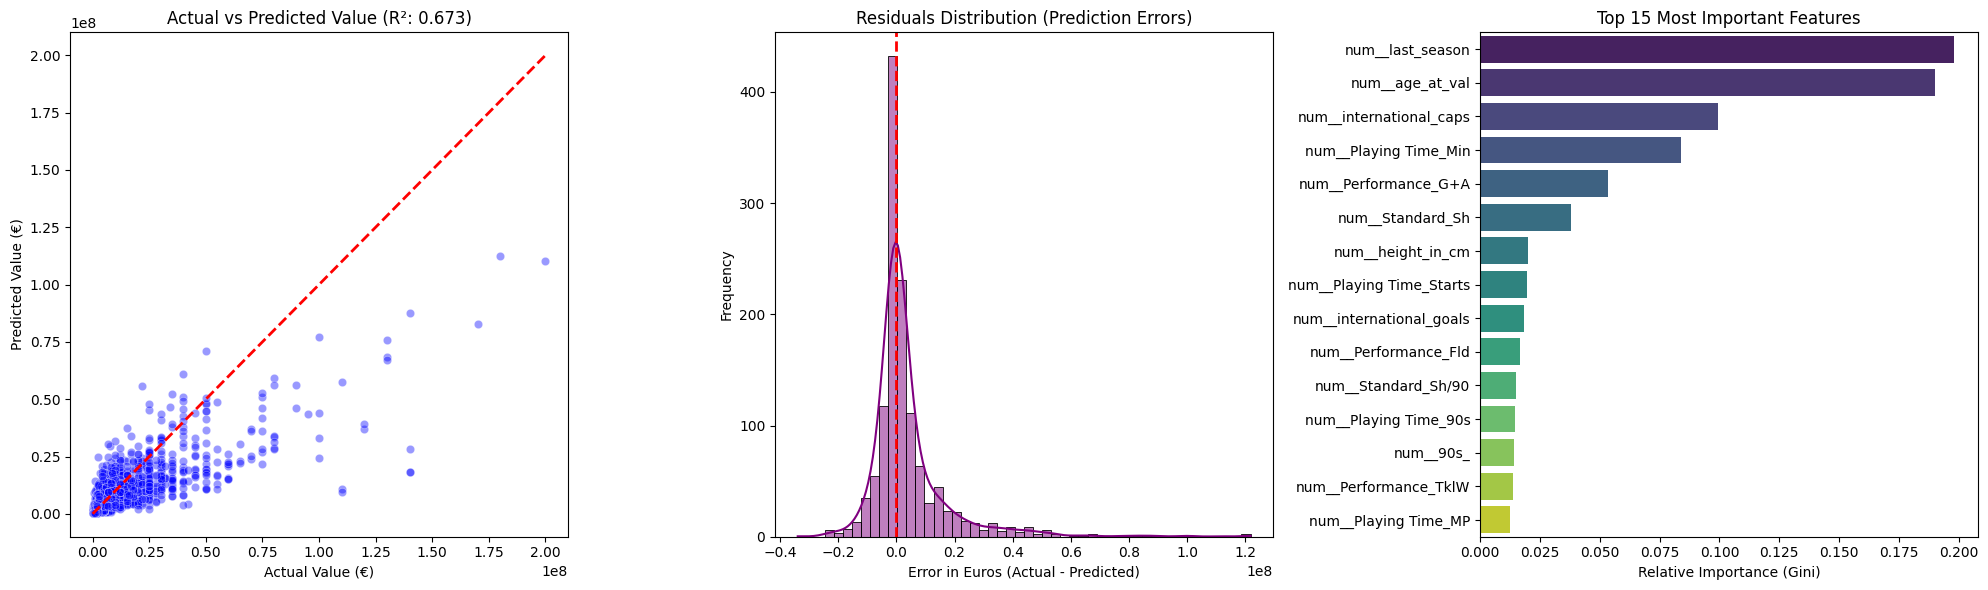

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the Hyperparameter Grid
param_dist = {
    'n_estimators': [100, 200, 300],            # Number of trees
    'max_depth': [None, 15, 25, 35],            # Maximum depth of trees
    'min_samples_split': [2, 5, 10],            # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],              # Minimum samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', 1.0]       # Number of features to consider at every split
}

# 2. Initialize RandomizedSearchCV
rf = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,          # Tests 15 random combinations
    cv=3,               # 3-fold cross-validation
    scoring='r2',       # Optimize for R-squared
    verbose=2,          # Shows progress in terminal
    random_state=42,
    n_jobs=-1           # Use all CPU cores
)

print("Starting Hyperparameter Tuning... (This may take a few minutes)")
random_search.fit(X_train_encoded, y_train)

# 3. Extract the Best Model and Predict
best_rf = random_search.best_estimator_
print(f"Best Parameters Found: {random_search.best_params_}")

y_pred_best = best_rf.predict(X_test_encoded)
best_r2 = r2_score(y_test, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_best)))

print(f"Tuned R²: {best_r2:.4f}")
print(f"Tuned RMSE: €{best_rmse:,.2f}")

# ==========================================
# EVALUATION PLOTS
# ==========================================
# Convert log predictions back to Euros for interpretable plots
y_test_eur = np.expm1(y_test)
y_pred_eur = np.expm1(y_pred_best)
residuals = y_test_eur - y_pred_eur

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Actual vs Predicted (Visualizing R²)
sns.scatterplot(x=y_test_eur, y=y_pred_eur, alpha=0.4, ax=axes[0], color='blue')
axes[0].plot([y_test_eur.min(), y_test_eur.max()], [y_test_eur.min(), y_test_eur.max()], 'r--', lw=2)
axes[0].set_title(f'Actual vs Predicted Value (R²: {best_r2:.3f})')
axes[0].set_xlabel('Actual Value (€)')
axes[0].set_ylabel('Predicted Value (€)')

# Plot 2: Residuals (Visualizing Loss/Error)
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residuals Distribution (Prediction Errors)')
axes[1].set_xlabel('Error in Euros (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

# Plot 3: Top 15 Feature Importances
importances = best_rf.feature_importances_
feature_names = X_train_encoded.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_features = feature_df.sort_values(by='Importance', ascending=False).head(15)

sns.barplot(x='Importance', y='Feature', data=top_features, ax=axes[2], palette='viridis')
axes[2].set_title('Top 15 Most Important Features')
axes[2].set_xlabel('Relative Importance (Gini)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

In [6]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize XGBoost Regressor
# tree_method='hist' makes training significantly faster for large datasets
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist', random_state=42)

# 2. Define the XGBoost Hyperparameter Grid
xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size shrinkage
    'max_depth': [3, 5, 7, 9],                # Max depth per tree (XGB prefers shallower trees than RF)
    'subsample': [0.7, 0.8, 0.9, 1.0],        # Percentage of rows used per tree
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0], # Percentage of columns used per tree
    'min_child_weight': [1, 3, 5]             # Minimum sum of instance weight needed in a child
}

# 3. Setup RandomizedSearchCV
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=20,          
    cv=3,               
    scoring='r2',       
    verbose=2,          
    random_state=42,
    n_jobs=-1           
)

print("Training XGBoost... (This handles outliers much better)")
xgb_search.fit(X_train_encoded, y_train)

# 4. Evaluate Best XGBoost Model
best_xgb = xgb_search.best_estimator_
print(f"\nBest XGB Parameters: {xgb_search.best_params_}")

y_pred_xgb = best_xgb.predict(X_test_encoded)
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_xgb)))

print(f"XGBoost R²: {xgb_r2:.4f}")
print(f"XGBoost RMSE: €{xgb_rmse:,.2f}")

Training XGBoost... (This handles outliers much better)
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   0.8s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=3, min_child_weight=5, n_estimators=300, subsample=0.9; total time=   0.8s
[CV] END colsample_bytree=0.8, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=100, subsample=1.0; total time=   0.9s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=3, min_child_weight=1, n_estimators=300, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=5, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   1.0s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=5, min_child_weight=3, n_estimators=200, subsample=0.9; total time=   1.0s
[CV] END colsample_bytree=0.9, learning_rate=0.2, max_depth=5, min_child_

In [8]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]


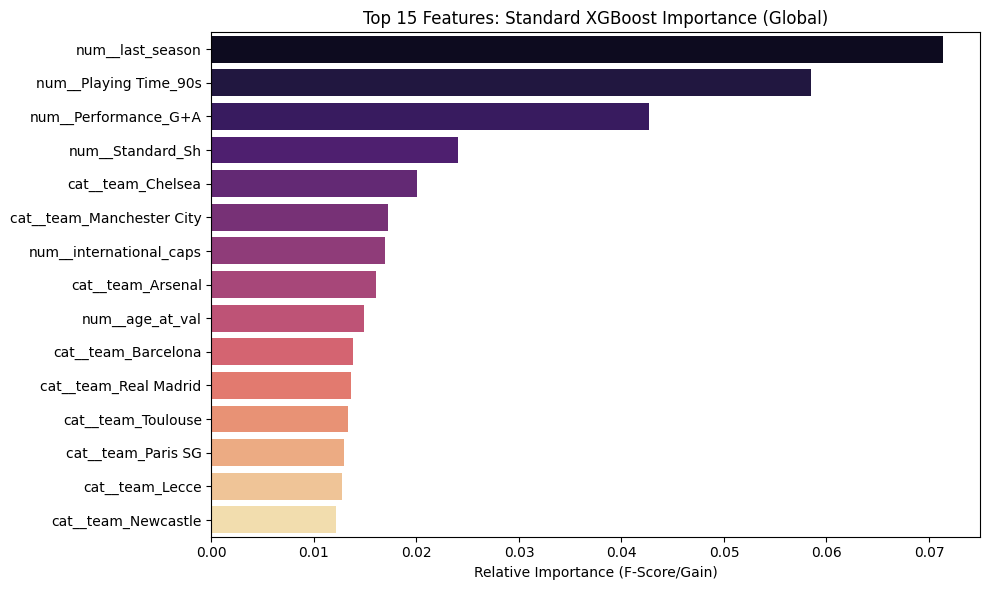

Calculating SHAP values... (This takes a few moments)


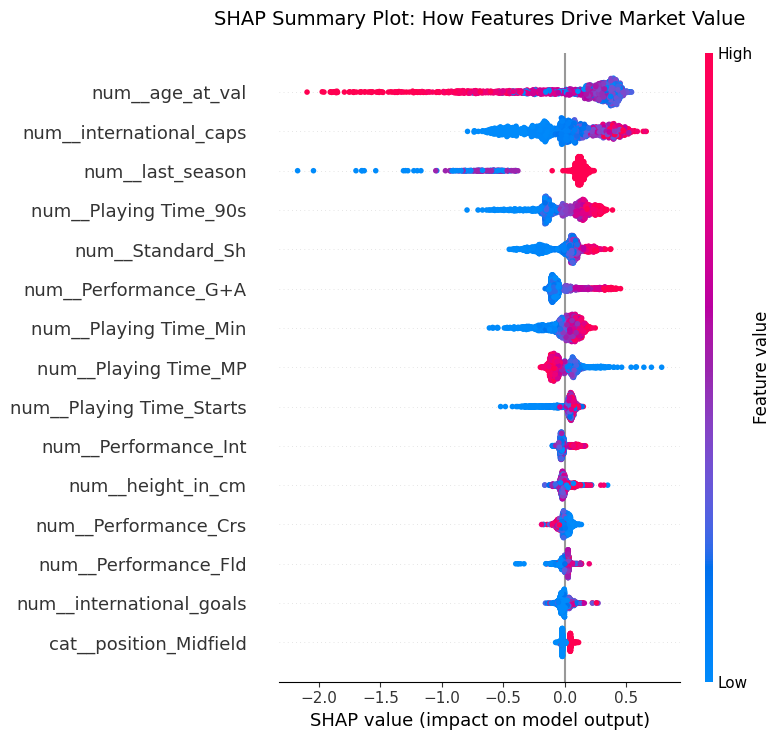

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import shap

# ==========================================
# 1. STANDARD XGBOOST FEATURE IMPORTANCE
# ==========================================
# Extract importances from the tuned model
xgb_importances = best_xgb.feature_importances_
feature_names = X_train_encoded.columns

xgb_feature_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x='Importance', y='Feature', data=xgb_feature_df, 
    ax=ax, palette='magma', hue='Feature', legend=False
)
ax.set_title('Top 15 Features: Standard XGBoost Importance (Global)')
ax.set_xlabel('Relative Importance (F-Score/Gain)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# ==========================================
# 2. SHAP VALUES (DIRECTIONAL IMPACT)
# ==========================================
print("Calculating SHAP values... (This takes a few moments)")

# Create the explainer using the trained XGBoost model
explainer = shap.TreeExplainer(best_xgb)

# Calculate SHAP values for the test set
# We use a sample of 1000 if the test set is massive to save memory, 
# but your dataset size should process the whole X_test_encoded quickly.
shap_values = explainer.shap_values(X_test_encoded)

# Plot the SHAP Summary
plt.figure(figsize=(12, 8))
plt.title("SHAP Summary Plot: How Features Drive Market Value", fontsize=14, pad=20)
shap.summary_plot(shap_values, X_test_encoded, max_display=15, show=False)
plt.tight_layout()
plt.show()

Background dataset has 5161 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5161 when initializing the masker.


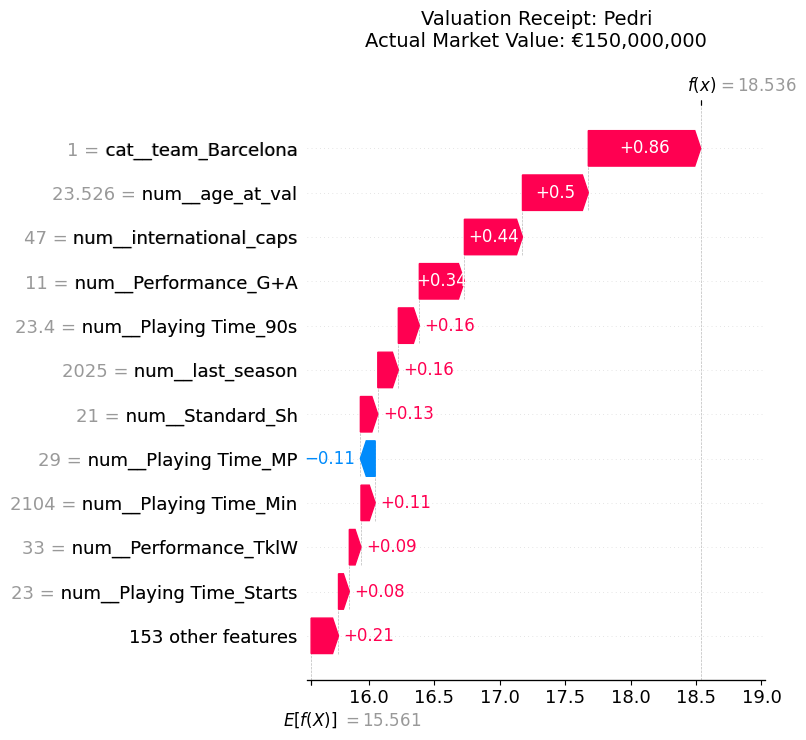

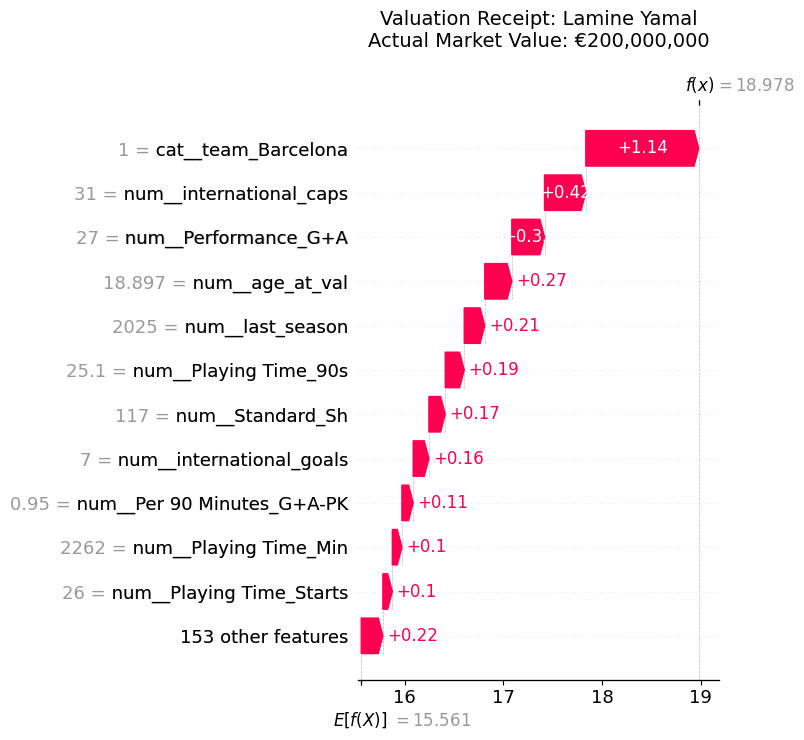

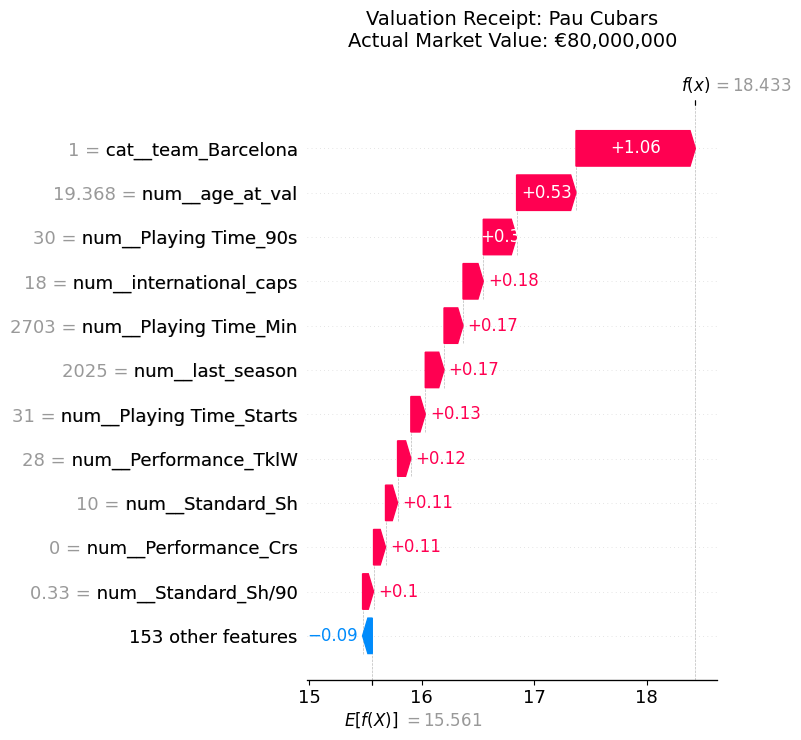

In [13]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the original dataset that still has the names
raw_df = pd.read_csv('data/final_model_data.csv')

def plot_player_receipt(player_name, explainer, preprocessor, raw_data, cat_cols, num_cols):
    # Find the player (using case-insensitive matching)
    player_row = raw_data[raw_data['name'].str.contains(player_name, case=False, na=False)].copy()
    
    if player_row.empty:
        print(f"Could not find {player_name} in the outfield dataset.")
        return
    
    # Take the most recent season if there are multiple entries
    player_row = player_row.sort_values(by='season', ascending=False).head(1)
    actual_value = player_row['market_value_in_eur_x'].values[0]
    
    # Apply identical Feature Engineering (Dates to Numbers)
    date_cols = ['date', 'date_of_birth', 'contract_expiration_date']
    for col in date_cols:
        if col in player_row.columns:
            player_row[col] = pd.to_datetime(player_row[col], errors='coerce')
            
    if 'date_of_birth' in player_row.columns and 'date' in player_row.columns:
        player_row['age_at_val'] = (player_row['date'] - player_row['date_of_birth']).dt.days / 365.25
    if 'contract_expiration_date' in player_row.columns and 'date' in player_row.columns:
        player_row['contract_days_left'] = (player_row['contract_expiration_date'] - player_row['date']).dt.days
        player_row['contract_days_left'] = player_row['contract_days_left'].fillna(0)
        
    # Fill categorical NAs to match training data
    for col in cat_cols:
        if col in player_row.columns:
            player_row[col] = player_row[col].fillna('Unknown')
            
    # Isolate the exact columns used in the trained model
    X_player = player_row[cat_cols + num_cols]
    
    # Transform using your fitted preprocessor
    X_player_encoded = pd.DataFrame(
        preprocessor.transform(X_player),
        columns=preprocessor.get_feature_names_out()
    )
    
    # Calculate SHAP values for this specific player
    shap_vals = explainer(X_player_encoded)
    
    # Create the Explanation object for the waterfall plot
    # Note: Values are in log-space, so we note the actual Euro value in the title
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_vals[0], max_display=12, show=False)
    plt.title(f"Valuation Receipt: {player_name}\nActual Market Value: €{actual_value:,.0f}", pad=20, fontsize=14)
    plt.tight_layout()
    plt.show()

# 2. Re-initialize the explainer using the newer SHAP API designed for waterfall plots
waterfall_explainer = shap.Explainer(best_xgb, X_train_encoded)

# 3. Generate the static receipts for the Barcelona trio
# 2. Re-initialize the explainer WITHOUT the background dataset
# This forces SHAP to use the model's internal tree paths, avoiding the split error
waterfall_explainer = shap.Explainer(best_xgb)

# 3. Generate the static receipts for the Barcelona trio
target_players = ["Pedri", "Lamine Yamal", "Pau Cubars"]

for player in target_players:
    plot_player_receipt(
        player_name=player, 
        explainer=waterfall_explainer, 
        preprocessor=preprocessor, 
        raw_data=raw_df, 
        cat_cols=cat_cols, 
        num_cols=num_cols
    )

In [14]:
import joblib
from pathlib import Path

# Create a folder for the final exported models
model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)

# 1. Save the trained XGBoost model
joblib.dump(best_xgb, model_dir / 'xgboost_valuation_model.joblib')

# 2. Save the fitted ColumnTransformer (Crucial for handling new input data)
joblib.dump(preprocessor, model_dir / 'valuation_preprocessor.joblib')

# 3. Save the exact column order to ensure future inputs match perfectly
final_feature_order = cat_cols + num_cols
joblib.dump(final_feature_order, model_dir / 'feature_order.joblib')

print("✅ Pipeline successfully saved to the 'models/' directory!")
print("You can now load this model in any Python script to predict player values.")

✅ Pipeline successfully saved to the 'models/' directory!
You can now load this model in any Python script to predict player values.
